# Lasso y Ridge desde cero

En este notebook aprenderemos una idea sencilla: a veces un modelo de regresión aprende **demasiado** de los datos que usamos para entrenarlo. Cuando eso ocurre, puede funcionar bien con los datos conocidos, pero equivocarse con datos nuevos. A esto le llamamos **sobreajuste**.

La regularización es una forma de pedirle al modelo que sea más prudente. El modelo debe hacer buenas predicciones, pero también debe evitar usar coeficientes demasiado grandes o demasiadas variables.

Veremos dos formas de regularizar:

- **Lasso (L1):** puede apagar algunas variables. Es decir, puede convertir sus coeficientes en cero. Por eso ayuda a seleccionar variables.
- **Ridge (L2):** normalmente conserva todas las variables, pero hace que sus coeficientes sean más pequeños. Por eso ayuda a estabilizar el modelo.

### Una comparación cotidiana

Imagina que varias personas quieren explicar por qué aumentaron las ventas. Lasso puede decir: “usaré solo a las personas más importantes y dejaré fuera a las demás”. Ridge puede decir: “escucharé a todas, pero daré menos peso a cada una”.

## ¿Qué significa L1 y L2?

Un coeficiente indica cuánto influye una variable en la predicción. Por ejemplo, un coeficiente grande para `horas_estudio` significa que esa variable tiene bastante influencia en la calificación estimada.

La regresión normal intenta reducir los errores de predicción. Lasso y Ridge agregan una pequeña “multa” cuando los coeficientes son grandes:

- **L1:** suma el valor absoluto de los coeficientes: `|coeficiente 1| + |coeficiente 2| + ...`. Esta forma de penalizar favorece que algunos coeficientes sean exactamente `0`.
- **L2:** suma los cuadrados de los coeficientes: `coeficiente 1² + coeficiente 2² + ...`. Esta forma reduce los coeficientes, pero normalmente no los convierte en cero.

En ambos casos usamos `alpha` para indicar qué tan fuerte es la multa. Un `alpha` pequeño aplica poca regularización. Un `alpha` grande aplica mucha regularización.

In [1]:
# Este bloque importa las herramientas necesarias.
# numpy crea datos numéricos y pandas organiza datos en tablas.
# matplotlib dibuja gráficas.
# scikit-learn contiene los modelos de regresión.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Fijamos una semilla para que los resultados sean iguales cada vez.
np.random.seed(42)
print('Todo está listo para comenzar.')

Todo está listo para comenzar.


# Ejercicio 1 — ¿Qué variables utiliza cada técnica?

## Situación

Queremos estimar la calificación de un estudiante. Tenemos cuatro datos:

- `horas_estudio`: horas que estudia.
- `asistencia`: porcentaje de clases a las que asiste.
- `color_mochila`: un dato sin relación real con la calificación.
- `numero_favorito`: otro dato sin relación real.

En un caso real no siempre sabemos qué variables son útiles. Lasso puede ayudarnos a descubrirlo. Ridge nos ayuda a conservar información, pero reduciendo el peso de los datos poco importantes.

In [2]:
# Creamos datos inventados para practicar. No necesitamos descargar ningún archivo.
rng = np.random.default_rng(42)
n = 120

datos = pd.DataFrame({
    'horas_estudio': rng.uniform(1, 10, n),
    'asistencia': rng.uniform(50, 100, n),
    'color_mochila': rng.integers(1, 6, n),
    'numero_favorito': rng.integers(1, 100, n)
})

# La calificación depende principalmente de las horas y la asistencia.
# El pequeño ruido representa factores que no medimos.
Y = pd.Series(4 + 0.45 * datos['horas_estudio']
                + 0.035 * datos['asistencia']
                + rng.normal(0, 0.35, n), name='Calificación (Y)')

print('Primeras filas de nuestros datos:')
display(datos.head())
print('Promedio de Y (calificación):', round(Y.mean(), 2))

Primeras filas de nuestros datos:


,horas_estudio,asistencia,color_mochila,numero_favorito
0,7.965604,79.204898,2,62
1,4.949906,82.492330,5,78
2,8.727381,54.222216,2,74
3,7.276312,70.790370,4,14
4,1.847596,52.080709,3,82


Promedio de Y (calificación): 9.06


### ¿Por qué dividimos los datos?

Separamos los datos en dos grupos:

- **Entrenamiento:** el modelo los utiliza para aprender.
- **Prueba:** el modelo no los ve durante el aprendizaje. Los usamos al final para saber si puede trabajar con información nueva.

Esta separación es como estudiar con unos ejercicios y después presentar un examen diferente. Si solo revisamos los ejercicios conocidos, no sabremos si realmente aprendimos.

### La diferencia entre X y Y

En aprendizaje automático casi siempre separamos los datos en dos partes:

- **X, con mayúscula:** es una tabla con las pistas o características. En este ejemplo, X contiene horas de estudio, asistencia, color de mochila y número favorito.
- **Y, con mayúscula:** es la respuesta correcta que queremos aprender a predecir. Aquí Y es la calificación.

Podemos decirlo así: el modelo recibe `X` y trata de calcular una estimación de `Y`. Durante el entrenamiento le mostramos ambos: `X_entrenamiento` y `Y_entrenamiento`. Después le damos solamente `X_prueba` y comparamos su predicción contra `Y_prueba`, que es la respuesta real.

Variables de entrada X:


,horas_estudio,asistencia,color_mochila,numero_favorito
0,7.965604,79.204898,2,62
1,4.949906,82.492330,5,78
2,8.727381,54.222216,2,74
3,7.276312,70.790370,4,14
4,1.847596,52.080709,3,82


Variable objetivo Y:


,Calificación (Y)
0,10.149807
1,9.321506
2,9.271541
3,10.268586
4,6.783168


Coeficientes aprendidos:


,Regresión normal,Lasso,Ridge
horas_estudio,1.063,0.989,1.051
asistencia,0.489,0.417,0.484
color_mochila,-0.040,-0.000,-0.040
numero_favorito,-0.025,-0.000,-0.026


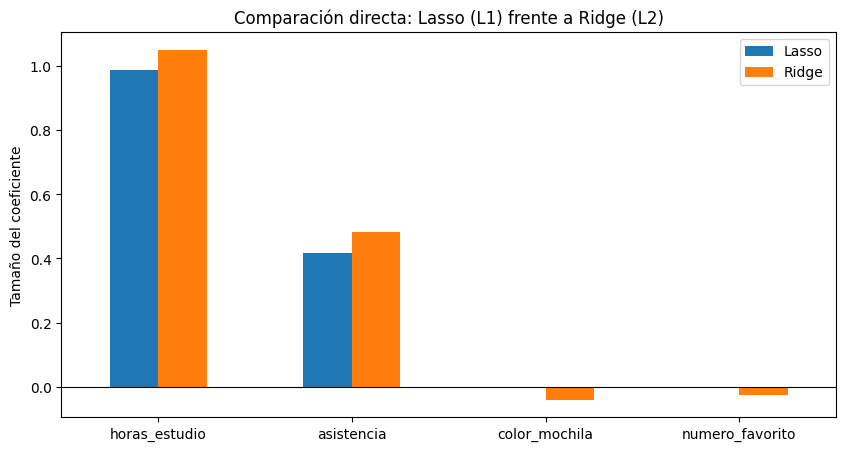

In [3]:
# X contiene las variables que usamos para explicar o predecir.
# Y contiene el resultado que queremos predecir: la calificación.
X = datos
print('Variables de entrada X:')
display(X.head())
print('Variable objetivo Y:')
display(Y.head())

X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba = train_test_split(
    X, Y, test_size=0.25, random_state=42
)

# Escalamos las variables para que todas tengan una importancia comparable.
# Por ejemplo, asistencia está entre 50 y 100, mientras que horas_estudio
# está entre 1 y 10. El escalado evita que esa diferencia de unidades
# afecte injustamente a Lasso o Ridge.

# A continuación creamos tres modelos para comparar: regresión normal,
# Lasso y Ridge. Los tres reciben exactamente el mismo X y el mismo Y.
# La única diferencia es la regla que usan para controlar los coeficientes.
# Lasso usa la penalización L1 y Ridge usa la penalización L2.

modelos = {
    'Regresión normal': Pipeline([
        ('escalador', StandardScaler()),
        ('modelo', LinearRegression())
    ]),
    'Lasso': Pipeline([
        ('escalador', StandardScaler()),
        ('modelo', Lasso(alpha=0.08, max_iter=10000))
    ]),
    'Ridge': Pipeline([
        ('escalador', StandardScaler()),
        ('modelo', Ridge(alpha=1))
    ])
}

for modelo in modelos.values():
    # Aquí cada modelo aprende la relación entre los datos y la calificación.
    modelo.fit(X_entrenamiento, Y_entrenamiento)

coeficientes = pd.DataFrame({
    nombre: modelo.named_steps['modelo'].coef_
    for nombre, modelo in modelos.items()
}, index=datos.columns)

print('Coeficientes aprendidos:')
display(coeficientes.round(3))

# Esta gráfica permite comparar visualmente Lasso y Ridge.
# Una barra más grande representa mayor influencia de esa variable.
# Una barra exactamente en cero significa que el modelo no la está usando.
coeficientes[['Lasso', 'Ridge']].plot(kind='bar', figsize=(10, 5))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Comparación directa: Lasso (L1) frente a Ridge (L2)')
plt.ylabel('Tamaño del coeficiente')
plt.xticks(rotation=0)
plt.show()

### Interpretación sencilla de los coeficientes

Observa la tabla anterior:

- En **Lasso**, los datos sin relación real suelen recibir coeficientes iguales o muy cercanos a cero. Esto significa: “no necesito usar esta variable”.
- En **Ridge**, esas variables normalmente conservan un coeficiente pequeño, pero no necesariamente cero. Esto significa: “la mantengo, aunque con poca influencia”.
- Las variables `horas_estudio` y `asistencia` deberían conservar los coeficientes más importantes porque son las que usamos para construir la calificación.

Como escalamos las variables, los coeficientes de esta tabla no están en las unidades originales. Para aprender la idea de L1 y L2 eso no es un problema: nos interesa comparar su tamaño y si son cero.

In [4]:
# Medimos el desempeño con datos de entrenamiento y con datos de prueba.
def medir(nombre, modelo):
    pred_entrenamiento = modelo.predict(X_entrenamiento)
    pred_prueba = modelo.predict(X_prueba)
    return {
        'Modelo': nombre,
        'Error entrenamiento (RMSE)': mean_squared_error(Y_entrenamiento, pred_entrenamiento) ** 0.5,
        'Error prueba (RMSE)': mean_squared_error(Y_prueba, pred_prueba) ** 0.5,
        'R² prueba': r2_score(Y_prueba, pred_prueba)
    }

tabla = pd.DataFrame([medir(nombre, modelo) for nombre, modelo in modelos.items()])
display(tabla.round(3))

print('RMSE: cuanto más pequeño, mejor. R²: cuanto más cercano a 1, mejor.')

# Buscamos el modelo con el menor error en los datos de prueba.
mejor_fila = tabla.loc[tabla['Error prueba (RMSE)'].idxmin()]
print(f"Conclusión del ejercicio 1: el mejor por RMSE de prueba fue {mejor_fila['Modelo']}.")
print(f"Su RMSE de prueba fue {mejor_fila['Error prueba (RMSE)']:.3f}.")

,Modelo,Error entrenamiento (RMSE),Error prueba (RMSE),R² prueba
0,Regresión normal,0.319,0.378,0.899
1,Lasso,0.341,0.357,0.910
2,Ridge,0.319,0.373,0.901


RMSE: cuanto más pequeño, mejor. R²: cuanto más cercano a 1, mejor.
Conclusión del ejercicio 1: el mejor por RMSE de prueba fue Lasso.
Su RMSE de prueba fue 0.357.


### ¿Cómo interpretamos las métricas?

El **RMSE** indica, aproximadamente, cuánto se equivoca el modelo en promedio. Por ejemplo, un RMSE de `0.40` significa que la predicción suele alejarse unas cuatro décimas de punto de la calificación real.

El **R²** indica qué tan bien explica el modelo los cambios de la calificación. Un valor cercano a `1` significa que explica gran parte de esos cambios.

En este ejercicio probablemente los tres modelos tendrán resultados parecidos, porque el problema es sencillo. La diferencia importante no está únicamente en quién gana por unas centésimas: está en cómo cada técnica trata las variables. Lasso produce un modelo más pequeño; Ridge produce un modelo más suave y estable.

### Conclusión concreta del ejercicio 1

La celda anterior identifica automáticamente al modelo con el menor RMSE en los datos de prueba. Ese es el **mejor modelo para predecir en este ejercicio**, según nuestra métrica.

Sin embargo, si los errores son muy parecidos, no sería correcto decir que uno es absolutamente mejor en todo. En ese caso:

- escogeríamos **Lasso** si queremos explicar la calificación usando solo las variables más importantes;
- escogeríamos **Ridge** si preferimos conservar todas las variables y reducir sus pesos.

La respuesta completa siempre debe mencionar las dos cosas: el resultado numérico y el objetivo del modelo.

# Ejercicio 2 — ¿Qué ocurre cuando dos variables dicen casi lo mismo?

Ahora imaginemos que medimos el estudio de dos maneras:

- `horas_biblioteca`: horas estudiadas en la biblioteca.
- `horas_casa`: horas estudiadas en casa.

Estas variables están relacionadas: quien estudia mucho en la biblioteca probablemente también estudia bastante en casa. Cuando dos variables se parecen, puede ser difícil para una regresión decidir cuánto peso dar a cada una. Este es un caso donde la diferencia entre Lasso y Ridge se vuelve más visible.

In [5]:
rng = np.random.default_rng(10)
n2 = 100
horas_biblioteca = rng.uniform(0, 8, n2)
horas_casa = horas_biblioteca + rng.normal(0, 0.4, n2)
X2 = pd.DataFrame({
    'horas_biblioteca': horas_biblioteca,
    'horas_casa': horas_casa
})
Y2 = pd.Series(5 + 0.8 * horas_biblioteca + 0.8 * horas_casa + rng.normal(0, 0.5, n2),
              name='Calificación (Y2)')

# Aquí X2 contiene las dos formas de medir el estudio.
# Y2 contiene la calificación que queremos predecir.
X2_ent, X2_pru, Y2_ent, Y2_pru = train_test_split(
    X2, Y2, test_size=0.25, random_state=42
)

lasso2 = Pipeline([('escalador', StandardScaler()), ('modelo', Lasso(alpha=0.15, max_iter=10000))])
ridge2 = Pipeline([('escalador', StandardScaler()), ('modelo', Ridge(alpha=1))])

lasso2.fit(X2_ent, Y2_ent)
ridge2.fit(X2_ent, Y2_ent)

comparacion = pd.DataFrame({
    'Lasso': lasso2.named_steps['modelo'].coef_,
    'Ridge': ridge2.named_steps['modelo'].coef_
}, index=X2.columns)
display(comparacion.round(3))

print('Lasso reparte la información de forma más selectiva.')
print('Ridge suele repartir el peso entre las dos variables parecidas.')

# También comparamos cuál predice mejor la Y de prueba en este ejercicio.
pred_lasso2 = lasso2.predict(X2_pru)
pred_ridge2 = ridge2.predict(X2_pru)
rmse_lasso2 = mean_squared_error(Y2_pru, pred_lasso2) ** 0.5
rmse_ridge2 = mean_squared_error(Y2_pru, pred_ridge2) ** 0.5
print(f'RMSE de prueba — Lasso: {rmse_lasso2:.3f}')
print(f'RMSE de prueba — Ridge: {rmse_ridge2:.3f}')
ganador2 = 'Lasso' if rmse_lasso2 < rmse_ridge2 else 'Ridge'
print(f'Conclusión del ejercicio 2: el mejor por RMSE de prueba fue {ganador2}.')

,Lasso,Ridge
horas_biblioteca,1.472,1.626
horas_casa,1.952,1.926


Lasso reparte la información de forma más selectiva.
Ridge suele repartir el peso entre las dos variables parecidas.
RMSE de prueba — Lasso: 0.461
RMSE de prueba — Ridge: 0.406
Conclusión del ejercicio 2: el mejor por RMSE de prueba fue Ridge.


### Conclusión concreta del ejercicio 2

Aquí consideramos “mejor” al modelo que tiene el menor RMSE al predecir `Y2_pru`. El notebook imprime el ganador automáticamente, porque el resultado puede cambiar si modificamos los datos o `alpha`.

Además del ganador numérico, observa los coeficientes: Lasso puede dar mucho más peso a una de las dos variables parecidas y reducir la otra; Ridge suele repartir el peso entre ambas. Por eso una técnica puede ganar ligeramente en error, mientras la otra puede ser más conveniente para explicar o conservar la información.

## ¿Cuándo debemos usar Lasso y cuándo Ridge?

Esta guía ayuda a elegir de forma sencilla:

### Elige Lasso cuando...

- Tienes muchas variables y sospechas que varias no son importantes.
- Quieres un modelo fácil de explicar, con pocas variables.
- Necesitas hacer una primera selección automática de variables.
- Te parece útil que algunas variables queden con coeficiente exactamente igual a cero.

**Ejemplo:** tienes 100 características de clientes, pero esperas que solo 10 sean realmente útiles para predecir una compra. Lasso puede ayudarte a dejar un modelo más pequeño.

### Elige Ridge cuando...

- Crees que la mayoría de las variables aporta algo de información.
- Tienes variables muy parecidas o correlacionadas entre sí.
- No quieres eliminar variables, sino reducir su influencia.
- Te importa que el modelo sea más estable cuando los datos cambian un poco.

**Ejemplo:** para predecir ventas tienes visitas en la página web, visitas en la aplicación y visitas en la tienda. Son mediciones distintas, pero relacionadas. Ridge suele repartir el peso entre ellas en lugar de escoger solo una.

### Si todavía tienes dudas

Prueba ambos modelos con los mismos datos y compara el error en datos de prueba. Si sus errores son parecidos, decide según el objetivo: Lasso si prefieres simplicidad y selección; Ridge si prefieres conservar información y estabilidad. En un proyecto real también puedes probar `LassoCV` y `RidgeCV`, que ayudan a elegir automáticamente un buen valor de `alpha` usando validación cruzada.

### Regla rápida para recordar

**Muchas variables poco útiles → Lasso. Variables relacionadas que quieres conservar → Ridge.**

## Conclusiones con lenguaje sencillo

### Lasso (L1)

Lasso es como un filtro. Si una variable aporta muy poco, puede eliminarla dejando su coeficiente en cero. Esto hace que el modelo sea más fácil de explicar porque utiliza menos variables. Su desventaja es que, cuando varias variables son muy parecidas, puede elegir una y reducir demasiado las otras.

### Ridge (L2)

Ridge es como un regulador de volumen. No suele apagar completamente las variables; baja el volumen de todas para evitar que alguna tenga un peso exagerado. Cuando varias variables son parecidas, suele repartir el peso entre ellas.

### Diferencia principal

- Si queremos **seleccionar variables y tener un modelo sencillo**, Lasso suele ser una buena opción.
- Si queremos **conservar variables y obtener coeficientes más estables**, Ridge suele ser una buena opción.
- Ambos pueden ayudar a reducir el sobreajuste. La elección final debe hacerse comparando el desempeño en datos de prueba o mediante validación cruzada.

La idea más importante para recordar es: **L1 puede dejar variables fuera; L2 reduce el peso de las variables sin eliminarlas normalmente.**

## Actividad final para el estudiante

Prueba estos cambios y escribe qué observas:

1. Cambia `alpha=0.08` de Lasso por `alpha=1`. ¿Aparecen más coeficientes cercanos a cero?
2. Cambia `alpha=1` de Ridge por `alpha=20`. ¿Los coeficientes se hacen más pequeños?
3. Explica con tus propias palabras cuándo elegirías Lasso y cuándo elegirías Ridge.

No existe un `alpha` universalmente correcto. En un proyecto real se prueban varios valores y se elige el que funcione mejor con validación cruzada.